In [1]:
!pip install numpy pandas matplotlib scikit-learn tensorflow tqdm

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.models import Model

In [3]:
DATASET_PATH = r"C:\Users\Ayush\Desktop\new data\MRNet_v1"

In [4]:
import os

print(os.listdir(DATASET_PATH))

['kaggle', 'train', 'train-abnormal.csv', 'train-acl.csv', 'train-meniscus.csv', 'valid', 'valid-abnormal.csv', 'valid-acl.csv', 'valid-meniscus.csv']


In [5]:
train_labels = pd.read_csv(DATASET_PATH + "/train-acl.csv", header=None)
train_labels.columns = ["case", "acl"]

meniscus = pd.read_csv(DATASET_PATH + "/train-meniscus.csv", header=None)
train_labels["meniscus"] = meniscus[1]

abnormal = pd.read_csv(DATASET_PATH + "/train-abnormal.csv", header=None)
train_labels["abnormal"] = abnormal[1]

print(train_labels.head())

   case  acl  meniscus  abnormal
0     0    0         0         1
1     1    1         1         1
2     2    0         0         1
3     3    0         1         1
4     4    0         0         1


In [6]:
IMG_SIZE = 224

images = []
labels = []

for index, row in tqdm(train_labels.iterrows(), total=len(train_labels)):

    case = str(row["case"]).zfill(4)

    path = DATASET_PATH + "/train/sagittal/" + case + ".npy"

    if os.path.exists(path):

        mri = np.load(path)

        mid_slice = mri[mri.shape[0] // 2]

        img = np.resize(mid_slice, (IMG_SIZE, IMG_SIZE))

        img = np.stack((img,)*3, axis=-1)

        images.append(img)

        labels.append([row["acl"], row["meniscus"], row["abnormal"]])

100%|██████████| 1130/1130 [00:03<00:00, 295.76it/s]


In [7]:
X = np.array(images)
y = np.array(labels)

print("Image shape:", X.shape)
print("Label shape:", y.shape)

Image shape: (1130, 224, 224, 3)
Label shape: (1130, 3)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

In [10]:
x = base_model.output

x = Flatten()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)

output = Dense(3, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)


In [11]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [12]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=16
)

Epoch 1/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 1764s 31s/step - accuracy: 0.3750 - loss: 1.3375 - val_accuracy: 0.3540 - val_loss: 0.5926
Epoch 2/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 1607s 28s/step - accuracy: 0.3905 - loss: 0.5394 - val_accuracy: 0.3540 - val_loss: 0.5825
Epoch 3/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 1741s 30s/step - accuracy: 0.3905 - loss: 0.5424 - val_accuracy: 0.3540 - val_loss: 0.5763
Epoch 4/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 1864s 33s/step - accuracy: 0.3905 - loss: 0.5368 - val_accuracy: 0.3540 - val_loss: 0.5747
Epoch 5/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 1892s 33s/step - accuracy: 0.3905 - loss: 0.5337 - val_accuracy: 0.3540 - val_loss: 0.5815
Epoch 6/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 1842s 32s/step - accuracy: 0.3905 - loss: 0.5384 - val_accuracy: 0.3540 - val_loss: 0.5766
Epoch 7/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 1897s 33s/step - accuracy: 0.3905 - loss: 0.5340 - val_accuracy: 0.3540 - val_loss: 0.5758
Epoch 8/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 2319s 41s/step - accuracy: 0.3905 - loss: 0.5358 - val_accu

In [13]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

8/8 ━━━━━━━━━━━━━━━━━━━━ 94s 12s/step - accuracy: 0.3540 - loss: 0.5801
Test Loss: 0.5800967216491699
Test Accuracy: 0.3539822995662689


In [14]:
pred = model.predict(X_test[:5])

print(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
[[0.17424297 0.35538054 0.81561625]
 [0.17424297 0.35538054 0.81561625]
 [0.17424297 0.35538054 0.81561625]
 [0.17424297 0.35538054 0.81561625]
 [0.17424297 0.35538054 0.81561625]]


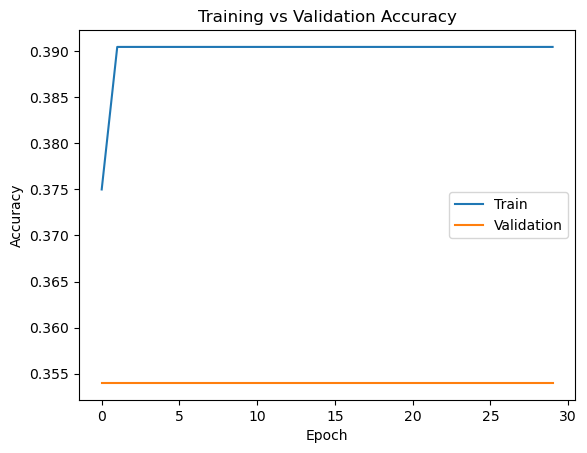

In [15]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])
plt.show()


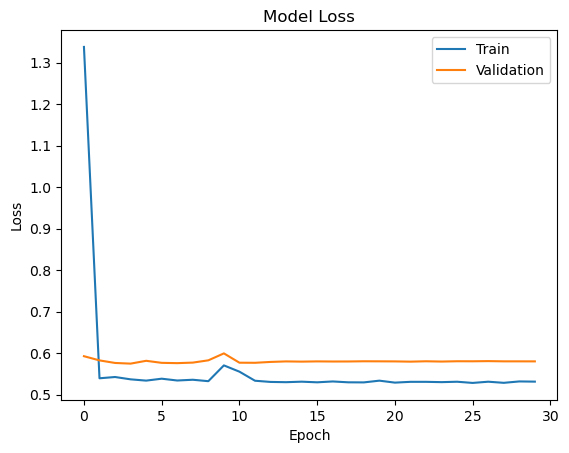

In [16]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train", "Validation"])
plt.show()

In [17]:
model.save("knee_injury_vgg16_model.h5")